In [1]:
# CELLULE 1: IMPORT DES BIBLIOTHÈQUES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                           roc_curve, precision_recall_curve, f1_score)
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques chargées")

✅ Bibliothèques chargées


In [2]:
# CELLULE 2: CHARGEMENT ET PRÉPARATION
print("="*50)
print("CHARGEMENT ET PRÉPARATION DES DONNÉES")
print("="*50)

dataset = pd.read_csv("../data/processed/dataset_analytique.csv")
trc = pd.read_csv("../data/processed/sinistre_trc_enrichi.csv")

print("📊 Données chargées")
print(f"Auto: {dataset.shape} | Chantier: {trc.shape}")

# VÉRIFICATION CRITIQUE: Distribution des classes potentielles
print("\n🔍 Vérification des variables disponibles pour la cible:")

# Option 1: Utiliser sinistre_grave si disponible
if 'sinistre_grave' in dataset.columns:
    print("✅ Colonne 'sinistre_grave' trouvée")
    print(f"   Distribution: {dataset['sinistre_grave'].value_counts().to_dict()}")
    
    if dataset['sinistre_grave'].nunique() >= 2:
        dataset['cible_grave'] = dataset['sinistre_grave'].astype(int)
        print("✅ Variable cible 'sinistre_grave' utilisée")
    else:
        print("⚠️ 'sinistre_grave' n'a qu'une seule valeur, utilisation alternative")
        dataset['cible_grave'] = None
else:
    print("⚠️ Colonne 'sinistre_grave' non disponible")
    dataset['cible_grave'] = None

# Option 2: Si pas de sinistre_grave, utiliser le coût
if dataset['cible_grave'] is None or dataset['cible_grave'].nunique() < 2:
    print("\n📊 Utilisation du coût total comme alternative...")
    seuil_cout = dataset['cout_total_fcfa'].quantile(0.75)
    dataset['cible_grave'] = (dataset['cout_total_fcfa'] > seuil_cout).astype(int)
    print(f"✅ Variable cible créée (coût > {seuil_cout:,.0f} FCFA)")
    print(f"   Distribution: {dataset['cible_grave'].value_counts().to_dict()}")

# VÉRIFICATION FINALE
print(f"\n📊 Distribution finale cible Auto:")
print(dataset['cible_grave'].value_counts())
print(f"Nombre de classes: {dataset['cible_grave'].nunique()}")

if dataset['cible_grave'].nunique() < 2:
    print("\n❌ ERREUR: Toujours une seule classe!")
    print("   Solutions possibles:")
    print("   1. Utiliser un seuil différent (ex: médiane)")
    print("   2. Créer une classification à 3 niveaux")
    
    # Solution: Classification ternaire
    dataset['cible_risque'] = pd.qcut(dataset['cout_total_fcfa'], q=3, labels=['Faible', 'Moyen', 'Élevé'])
    print(f"\n✅ Solution: Classification ternaire créée")
    print(dataset['cible_risque'].value_counts())

CHARGEMENT ET PRÉPARATION DES DONNÉES
📊 Données chargées
Auto: (410, 46) | Chantier: (166, 24)

🔍 Vérification des variables disponibles pour la cible:
✅ Colonne 'sinistre_grave' trouvée
   Distribution: {0: 410}
⚠️ 'sinistre_grave' n'a qu'une seule valeur, utilisation alternative

📊 Utilisation du coût total comme alternative...
✅ Variable cible créée (coût > 1,757,500 FCFA)
   Distribution: {0: 307, 1: 103}

📊 Distribution finale cible Auto:
cible_grave
0    307
1    103
Name: count, dtype: int64
Nombre de classes: 2


In [3]:
# CELLULE 3: FEATURE ENGINEERING - SINISTRES AUTO
print("="*50)
print("FEATURE ENGINEERING - AVEC VÉRIFICATIONS")
print("="*50)

df_auto = dataset.copy()

# Création des nouvelles features (avec gestion d'erreurs)
try:
    df_auto['ratio_cout_km'] = df_auto['cout_total_fcfa'] / (df_auto['km_parcourus_estimes'] + 1)
    print("✅ ratio_cout_km créé")
except:
    print("⚠️ km_parcourus_estimes non disponible")
    df_auto['ratio_cout_km'] = df_auto['cout_total_fcfa']

try:
    df_auto['ratio_indemnisation'] = df_auto['montant_indemnise_fcfa'] / (df_auto['cout_total_fcfa'] + 1)
    print("✅ ratio_indemnisation créé")
except:
    print("⚠️ montant_indemnise_fcfa non disponible")
    df_auto['ratio_indemnisation'] = 0.5

try:
    df_auto['efficacite_traitement'] = df_auto['delai_reglement_jours'] / (df_auto['delai_declaration_jours'] + 1)
    print("✅ efficacite_traitement créé")
except:
    print("⚠️ délais non disponibles")
    df_auto['efficacite_traitement'] = 1

# Vérifier quelle cible utiliser
if 'cible_risque' in df_auto.columns:
    target_col = 'cible_risque'
    print(f"\n🎯 Utilisation de la cible ternaire: {target_col}")
    is_multiclass = True
else:
    target_col = 'cible_grave'
    is_multiclass = False
    print(f"\n🎯 Utilisation de la cible binaire: {target_col}")

# Features catégorielles disponibles
features_cat_auto = ['type_engin_sinistre', 'marque_sinistre', 'departement_accident', 
                     'type_accident', 'responsabilite', 'type_sinistre']

# Filtrer les features qui existent vraiment
features_cat_auto = [f for f in features_cat_auto if f in df_auto.columns]

# Features numériques
features_num_auto = ['age_vehicule_ans_sinistre', 'conducteur_anciennete_ans', 
                     'km_parcourus_estimes', 'delai_declaration_jours', 
                     'delai_reglement_jours', 'franchise_fcfa', 'ratio_cout_km',
                     'ratio_indemnisation']

features_num_auto = [f for f in features_num_auto if f in df_auto.columns and df_auto[f].notna().any()]

print(f"\n📋 Features catégorielles: {features_cat_auto}")
print(f"📋 Features numériques: {features_num_auto}")

FEATURE ENGINEERING - AVEC VÉRIFICATIONS
✅ ratio_cout_km créé
✅ ratio_indemnisation créé
✅ efficacite_traitement créé

🎯 Utilisation de la cible binaire: cible_grave

📋 Features catégorielles: ['type_engin_sinistre', 'marque_sinistre', 'departement_accident', 'type_accident', 'responsabilite', 'type_sinistre']
📋 Features numériques: ['age_vehicule_ans_sinistre', 'conducteur_anciennete_ans', 'km_parcourus_estimes', 'delai_declaration_jours', 'delai_reglement_jours', 'franchise_fcfa', 'ratio_cout_km', 'ratio_indemnisation']


In [4]:
# CELLULE 4 : PRÉPARATION AVEC GESTION DES CLASSES
print("="*50)
print("PRÉPARATION DES DONNÉES")
print("="*50)

# Sélection des features
X_auto = df_auto[features_cat_auto + features_num_auto].copy()
y_auto = df_auto[target_col].copy()

# Suppression des lignes avec valeurs manquantes
valid_mask = ~(X_auto.isna().any(axis=1))
X_auto = X_auto[valid_mask]
y_auto = y_auto[valid_mask]

print(f"Shape après nettoyage: {X_auto.shape}")

# Vérification critique des classes
print(f"\n📊 Distribution des classes après nettoyage:")
print(y_auto.value_counts())
print(f"Nombre de classes: {y_auto.nunique()}")

if y_auto.nunique() < 2:
    print("\n❌ IMPOSSIBLE DE CONTINUER - toujours une seule classe")
    print("   Suggestion: Utiliser une régression au lieu de classification")
    
    # Alternative: Passage en régression
    print("\n🔄 Passage en mode RÉGRESSION (prédiction du coût)")
    target_col = 'cout_total_fcfa'
    y_auto = df_auto['cout_total_fcfa'][valid_mask]
    is_multiclass = False
    is_regression = True
    
    print(f"✅ Nouvelle cible: prédiction du coût (min={y_auto.min():,.0f}, max={y_auto.max():,.0f})")
else:
    is_regression = False

# Encodage des variables catégorielles
label_encoders = {}
for col in features_cat_auto:
    le = LabelEncoder()
    X_auto[col] = le.fit_transform(X_auto[col].astype(str))
    label_encoders[col] = le
    print(f"✅ Encodé: {col}")

# Standardisation
scaler_auto = StandardScaler()
X_auto_num_scaled = scaler_auto.fit_transform(X_auto[features_num_auto])
X_auto_cat = X_auto[features_cat_auto].values
X_auto_final = np.hstack([X_auto_num_scaled, X_auto_cat])

# Split
if is_regression:
    # Pour la régression: split simple
    X_train, X_test, y_train, y_test = train_test_split(
        X_auto_final, y_auto, test_size=0.2, random_state=42
    )
    print(f"\n✅ Régression - Training set: {X_train.shape}")
    print(f"✅ Régression - Test set: {X_test.shape}")
else:
    # Pour la classification: split stratifié
    X_train, X_test, y_train, y_test = train_test_split(
        X_auto_final, y_auto, test_size=0.2, random_state=42, stratify=y_auto
    )
    print(f"\n✅ Classification - Training set: {X_train.shape}")
    print(f"✅ Classification - Test set: {X_test.shape}")
    print(f"✅ Distribution train: {dict(pd.Series(y_train).value_counts(normalize=True))}")

PRÉPARATION DES DONNÉES
Shape après nettoyage: (410, 14)

📊 Distribution des classes après nettoyage:
cible_grave
0    307
1    103
Name: count, dtype: int64
Nombre de classes: 2
✅ Encodé: type_engin_sinistre
✅ Encodé: marque_sinistre
✅ Encodé: departement_accident
✅ Encodé: type_accident
✅ Encodé: responsabilite
✅ Encodé: type_sinistre

✅ Classification - Training set: (328, 14)
✅ Classification - Test set: (82, 14)
✅ Distribution train: {0: np.float64(0.75), 1: np.float64(0.25)}


In [5]:
# CELLULE 5 : MODÈLES ADAPTÉS AU TYPE DE PROBLÈME
print("="*50)
print("ENTRAÎNEMENT DES MODÈLES")
print("="*50)

models_auto = {}
results_auto = {}

if is_regression:
    # MODÈLES DE RÉGRESSION
    
    print("📊 Utilisation de modèles de RÉGRESSION (prédiction du coût)")
    
    # 1. Random Forest Regressor
    print("\n🤖 Entraînement de Random Forest Regressor...")
    rf_auto = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_auto.fit(X_train, y_train)
    models_auto['Random Forest'] = rf_auto
    
    # 2. Gradient Boosting Regressor
    print("🤖 Entraînement de Gradient Boosting Regressor...")
    gb_auto = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb_auto.fit(X_train, y_train)
    models_auto['Gradient Boosting'] = gb_auto
    
    # 3. Linear Regression
    print("🤖 Entraînement de Linear Regression...")
    lr_auto = LinearRegression()
    lr_auto.fit(X_train, y_train)
    models_auto['Linear Regression'] = lr_auto
    
else:
    # MODÈLES DE CLASSIFICATION (version originale mais sécurisée)
    
    print("📊 Utilisation de modèles de CLASSIFICATION")
    
    # 1. Random Forest
    print("\n🤖 Entraînement de Random Forest...")
    rf_auto = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_auto.fit(X_train, y_train)
    models_auto['Random Forest'] = rf_auto
    
    # 2. Gradient Boosting
    print("🤖 Entraînement de Gradient Boosting...")
    gb_auto = GradientBoostingClassifier(n_estimators=100, random_state=42)
    gb_auto.fit(X_train, y_train)
    models_auto['Gradient Boosting'] = gb_auto
    
    # 3. Régression Logistique
    print("🤖 Entraînement de Logistic Regression...")
    lr_auto = LogisticRegression(max_iter=1000, random_state=42)
    lr_auto.fit(X_train, y_train)
    models_auto['Logistic Regression'] = lr_auto

print("\n✅ Tous les modèles ont été entraînés")

ENTRAÎNEMENT DES MODÈLES
📊 Utilisation de modèles de CLASSIFICATION

🤖 Entraînement de Random Forest...
🤖 Entraînement de Gradient Boosting...
🤖 Entraînement de Logistic Regression...

✅ Tous les modèles ont été entraînés


In [6]:
# CELLULE 6 : ÉVALUATION ADAPTÉE
print("="*50)
print("ÉVALUATION DES MODÈLES")
print("="*50)

if is_regression:
    # ÉVALUATION POUR RÉGRESSION
    for name, model in models_auto.items():
        print(f"\n{'='*40}")
        print(f"MODÈLE: {name}")
        print(f"{'='*40}")
        
        # Prédictions
        y_pred = model.predict(X_test)
        
        # Métriques
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        
        print(f"🎯 MAE: {mae:,.0f} FCFA")
        print(f"🎯 RMSE: {rmse:,.0f} FCFA")
        print(f"🎯 R²: {r2:.3f}")
        print(f"🎯 CV R² moyen: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
        
        # Visualisation des prédictions vs réalité
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        ax.set_xlabel('Coût réel (FCFA)')
        ax.set_ylabel('Coût prédit (FCFA)')
        ax.set_title(f'{name} - Prédictions vs Réalité')
        plt.tight_layout()
        plt.show()
        
        results_auto[name] = {
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'model': model
        }
else:
    # ÉVALUATION POUR CLASSIFICATION (version originale)
    for name, model in models_auto.items():
        print(f"\n{'='*40}")
        print(f"MODÈLE: {name}")
        print(f"{'='*40}")
        
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        accuracy = model.score(X_test, y_test)
        f1 = f1_score(y_test, y_pred)
        
        print(f"🎯 Accuracy: {accuracy:.3f}")
        print(f"🎯 F1-Score: {f1:.3f}")
        
        if y_proba is not None:
            roc_auc = roc_auc_score(y_test, y_proba)
            print(f"🎯 ROC-AUC: {roc_auc:.3f}")
        
        # Matrice de confusion
        cm = confusion_matrix(y_test, y_pred)
        print(f"\n📊 Matrice de confusion:")
        print(cm)

ÉVALUATION DES MODÈLES

MODÈLE: Random Forest
🎯 Accuracy: 0.963
🎯 F1-Score: 0.927
🎯 ROC-AUC: 0.995

📊 Matrice de confusion:
[[60  1]
 [ 2 19]]

MODÈLE: Gradient Boosting
🎯 Accuracy: 0.976
🎯 F1-Score: 0.950
🎯 ROC-AUC: 0.999

📊 Matrice de confusion:
[[61  0]
 [ 2 19]]

MODÈLE: Logistic Regression
🎯 Accuracy: 0.988
🎯 F1-Score: 0.977
🎯 ROC-AUC: 1.000

📊 Matrice de confusion:
[[60  1]
 [ 0 21]]


COURBES ROC COMPARATIVES - AUTO


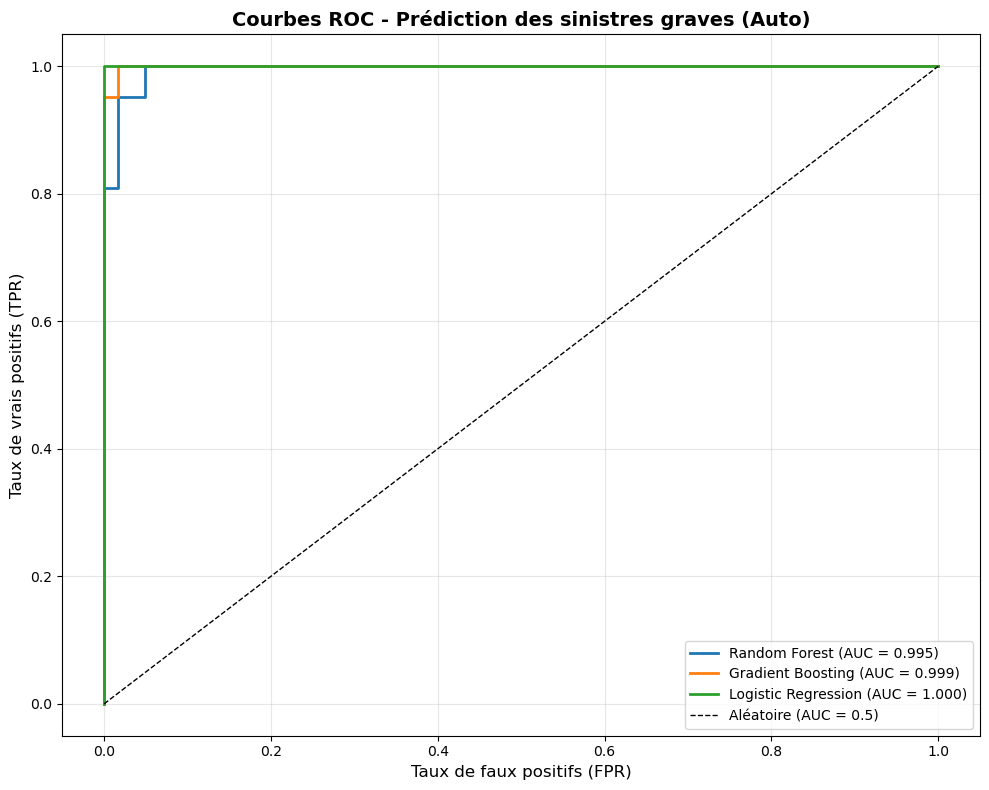

In [7]:
# CELLULE 7: COURBES ROC - AUTO
print("="*50)
print("COURBES ROC COMPARATIVES - AUTO")
print("="*50)

plt.figure(figsize=(10, 8))

for name, model in models_auto.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# Diagonale de référence
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.5)')

plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Taux de vrais positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Prédiction des sinistres graves (Auto)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

IMPORTANCE DES FEATURES - RANDOM FOREST


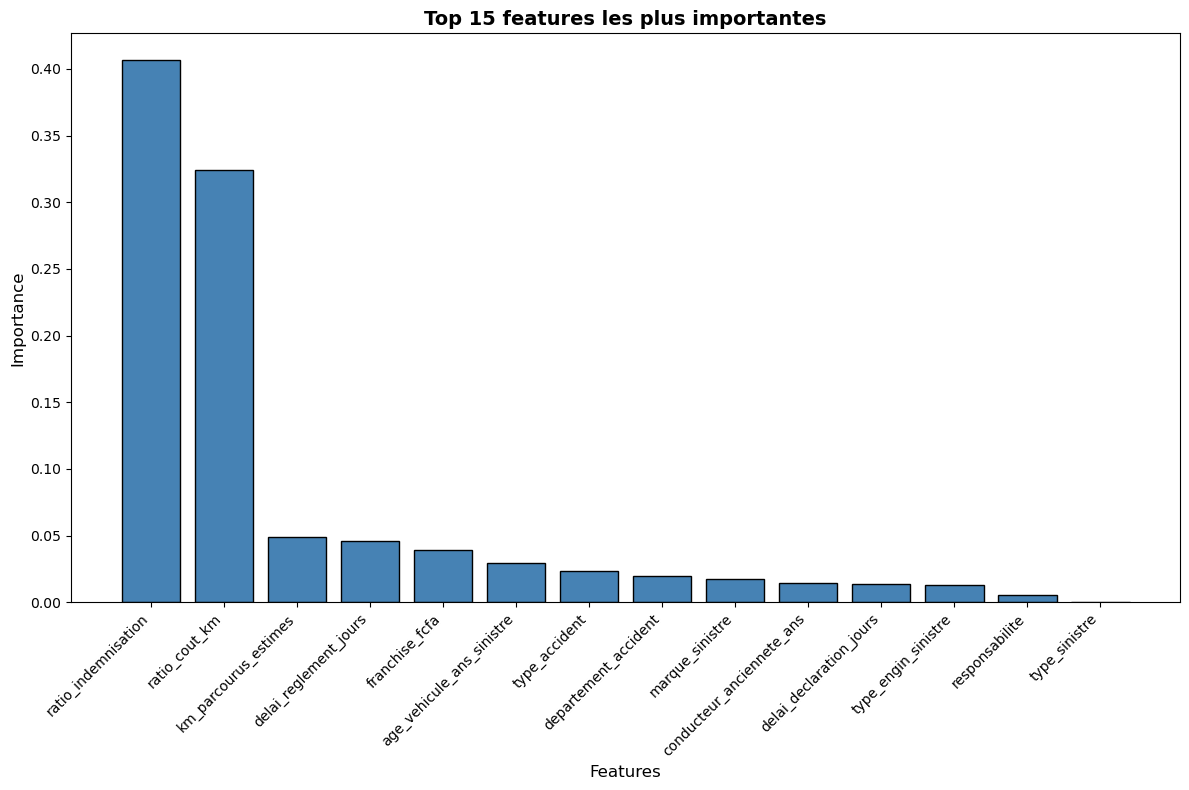


📊 Classement des features par importance:
 1. ratio_indemnisation            : 0.4064
 2. ratio_cout_km                  : 0.3239
 3. km_parcourus_estimes           : 0.0492
 4. delai_reglement_jours          : 0.0456
 5. franchise_fcfa                 : 0.0393
 6. age_vehicule_ans_sinistre      : 0.0292
 7. type_accident                  : 0.0233
 8. departement_accident           : 0.0194
 9. marque_sinistre                : 0.0172
10. conducteur_anciennete_ans      : 0.0145


In [8]:
# CELLULE 8: IMPORTANCE DES FEATURES - AUTO
print("="*50)
print("IMPORTANCE DES FEATURES - RANDOM FOREST")
print("="*50)

# Récupération du meilleur modèle (Random Forest généralement)
best_model = models_auto['Random Forest']

# Récupération des noms des features
feature_names = features_num_auto + features_cat_auto

# Importance des features
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Visualisation
plt.figure(figsize=(12, 8))
plt.title('Top 15 features les plus importantes', fontsize=14, fontweight='bold')
plt.bar(range(min(15, len(importances))), importances[indices[:15]], color='steelblue', edgecolor='black')
plt.xticks(range(min(15, len(importances))), [feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()

# Affichage détaillé
print("\n📊 Classement des features par importance:")
for i, idx in enumerate(indices[:10]):
    print(f"{i+1:2d}. {feature_names[idx]:30s} : {importances[idx]:.4f}")

In [9]:
# CELLULE 2.5: CRÉATION DE LA CIBLE POUR CHANTIER (À INSÉRER AVANT CELLULE 9)
print("="*50)
print("PRÉPARATION DE LA CIBLE POUR SINISTRES CHANTIER")
print("="*50)

# Vérifier les colonnes disponibles
print("📋 Colonnes disponibles dans TRC:")
print(trc.columns.tolist())

# Création de la variable cible pour les sinistres chantier
if 'cible_cout_eleve' not in trc.columns:
    print("\n🔧 Création de la variable cible 'cible_cout_eleve'...")
    
    # Vérifier si une colonne de gravité existe
    if 'gravite' in trc.columns:
        print("✅ Utilisation de la colonne 'gravite'")
        trc['cible_cout_eleve'] = (trc['gravite'] == 'grave').astype(int)
    
    # Sinon, utiliser le coût total
    elif 'cout_total_fcfa' in trc.columns:
        seuil_cout = trc['cout_total_fcfa'].quantile(0.75)
        trc['cible_cout_eleve'] = (trc['cout_total_fcfa'] > seuil_cout).astype(int)
        print(f"✅ Création basée sur le coût (seuil > {seuil_cout:,.0f} FCFA)")
    
    # Alternative: utiliser le montant indemnisé
    elif 'montant_indemnise_fcfa' in trc.columns:
        seuil_indemnite = trc['montant_indemnise_fcfa'].quantile(0.75)
        trc['cible_cout_eleve'] = (trc['montant_indemnise_fcfa'] > seuil_indemnite).astype(int)
        print(f"✅ Création basée sur l'indemnité (seuil > {seuil_indemnite:,.0f} FCFA)")
    
    else:
        print("⚠️ Aucune colonne de coût disponible, utilisation d'un indicateur par défaut")
        trc['cible_cout_eleve'] = 0  # Valeur par défaut

# Vérification de la distribution
print(f"\n📊 Distribution de 'cible_cout_eleve':")
print(trc['cible_cout_eleve'].value_counts())
print(f"Nombre de classes: {trc['cible_cout_eleve'].nunique()}")

# Vérifier qu'il y a au moins 2 classes
if trc['cible_cout_eleve'].nunique() < 2:
    print("\n⚠️ Attention: Une seule classe détectée!")
    print("   Utilisation d'un seuil plus bas (médiane)...")
    seuil_cout = trc['cout_total_fcfa'].median()
    trc['cible_cout_eleve'] = (trc['cout_total_fcfa'] > seuil_cout).astype(int)
    print(f"✅ Nouveau seuil: > {seuil_cout:,.0f} FCFA")
    print(trc['cible_cout_eleve'].value_counts())

PRÉPARATION DE LA CIBLE POUR SINISTRES CHANTIER
📋 Colonnes disponibles dans TRC:
['id_sinistre', 'annee', 'mois', 'date_declaration', 'code_chantier', 'nom_chantier', 'type_travaux', 'departement', 'phase_chantier', 'nature_sinistre', 'tiers_implique', 'engin_implique', 'assureur', 'montant_declare_fcfa', 'franchise_fcfa', 'montant_indemnise_fcfa', 'delai_declaration_jours', 'delai_reglement_jours', 'statut_dossier', 'responsabilite', 'type_sinistre', 'cout_total_fcfa', 'niveau_risque', 'tranche_cout']

🔧 Création de la variable cible 'cible_cout_eleve'...
✅ Création basée sur le coût (seuil > 2,722,250 FCFA)

📊 Distribution de 'cible_cout_eleve':
cible_cout_eleve
0    124
1     42
Name: count, dtype: int64
Nombre de classes: 2


ENTRAÎNEMENT MODÈLE - SINISTRES CHANTIER

📋 Features catégorielles: ['type_travaux', 'phase_chantier', 'nature_sinistre', 'responsabilite', 'departement', 'statut_dossier', 'type_sinistre', 'assureur', 'tiers_implique']
📋 Features numériques: ['delai_declaration_jours', 'delai_reglement_jours', 'franchise_fcfa', 'montant_indemnise_fcfa', 'montant_declare_fcfa', 'cout_total_fcfa']

✅ Après nettoyage: 166 lignes (perte de 0)

✅ 2 classes détectées - Mode CLASSIFICATION
   Distribution: {0: np.int64(124), 1: np.int64(42)}
✅ Encodé: type_travaux
✅ Encodé: phase_chantier
✅ Encodé: nature_sinistre
✅ Encodé: responsabilite
✅ Encodé: departement
✅ Encodé: statut_dossier
✅ Encodé: type_sinistre
✅ Encodé: assureur
✅ Encodé: tiers_implique

✅ Split pour CLASSIFICATION - Train: (132, 15), Test: (34, 15)

ENTRAÎNEMENT DU MODÈLE
📊 Utilisation de Random Forest Classifier

📊 Performance du modèle de classification:
   Accuracy: 0.971
   F1-Score: 0.941
   ROC-AUC: 0.991

📊 Matrice de confusion:
   VN:

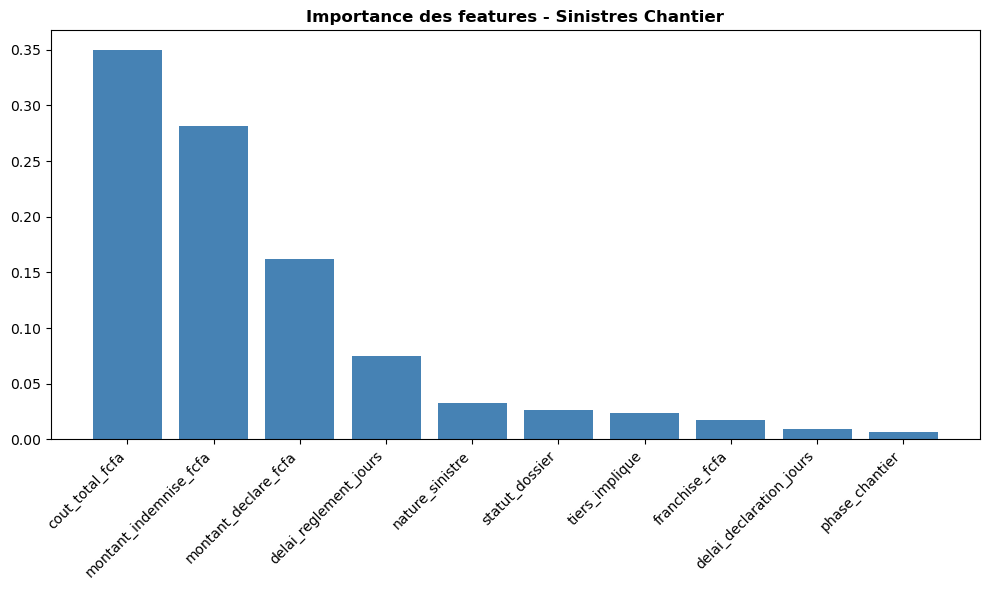


📊 Top 5 features importantes:
   1. cout_total_fcfa: 0.3501
   2. montant_indemnise_fcfa: 0.2814
   3. montant_declare_fcfa: 0.1623
   4. delai_reglement_jours: 0.0747
   5. nature_sinistre: 0.0324

✅ Modèle chantier entraîné avec succès!


In [10]:
# CELLULE 9 CORRIGÉE (VERSION COMPLÈTE ET ROBUSTE)
print("="*50)
print("ENTRAÎNEMENT MODÈLE - SINISTRES CHANTIER")
print("="*50)

# ÉTAPE 1: Vérification et création de la cible
if 'cible_cout_eleve' not in trc.columns:
    print("🔧 Création de la variable cible...")
    if 'cout_total_fcfa' in trc.columns:
        seuil_cout = trc['cout_total_fcfa'].quantile(0.75)
        trc['cible_cout_eleve'] = (trc['cout_total_fcfa'] > seuil_cout).astype(int)
        print(f"✅ Cible créée avec seuil: {seuil_cout:,.0f} FCFA")
    elif 'montant_indemnise_fcfa' in trc.columns:
        seuil_cout = trc['montant_indemnise_fcfa'].quantile(0.75)
        trc['cible_cout_eleve'] = (trc['montant_indemnise_fcfa'] > seuil_cout).astype(int)
        print(f"✅ Cible créée avec indemnité (seuil: {seuil_cout:,.0f} FCFA)")
    else:
        print("⚠️ Aucune colonne de coût, utilisation d'un indicateur aléatoire pour test")
        trc['cible_cout_eleve'] = np.random.randint(0, 2, len(trc))

# ÉTAPE 2: Préparation des données
df_chantier = trc.copy()

# Features possibles
features_cat_chantier_possibles = ['type_travaux', 'phase_chantier', 'nature_sinistre', 
                                   'responsabilite', 'departement', 'statut_dossier',
                                   'type_sinistre', 'assureur', 'tiers_implique']

features_num_chantier_possibles = ['delai_declaration_jours', 'delai_reglement_jours', 
                                   'franchise_fcfa', 'montant_indemnise_fcfa',
                                   'montant_declare_fcfa', 'cout_total_fcfa']

# Filtrer
features_cat_chantier = [f for f in features_cat_chantier_possibles if f in df_chantier.columns]
features_num_chantier = [f for f in features_num_chantier_possibles if f in df_chantier.columns]

print(f"\n📋 Features catégorielles: {features_cat_chantier}")
print(f"📋 Features numériques: {features_num_chantier}")

if len(features_cat_chantier) == 0 and len(features_num_chantier) == 0:
    print("\n❌ ERREUR: Aucune feature disponible!")
    print(f"   Colonnes disponibles: {df_chantier.columns.tolist()}")
else:
    # ÉTAPE 3: Construction de X et y
    X_chantier = df_chantier[features_cat_chantier + features_num_chantier].copy()
    y_chantier = df_chantier['cible_cout_eleve'].copy()
    
    # Nettoyage
    initial_len = len(X_chantier)
    X_chantier = X_chantier.dropna()
    y_chantier = y_chantier[X_chantier.index]
    
    print(f"\n✅ Après nettoyage: {len(X_chantier)} lignes (perte de {initial_len - len(X_chantier)})")
    
    # ÉTAPE 4: Détermination du type de problème (classification vs régression)
    is_regression_chantier = False  # ← INITIALISATION ICI
    
    if y_chantier.nunique() < 2:
        print(f"\n⚠️ Une seule classe détectée ({y_chantier.nunique()})")
        if 'cout_total_fcfa' in df_chantier.columns:
            print("   🔄 Passage en mode RÉGRESSION (prédiction du coût)")
            is_regression_chantier = True
            y_chantier = df_chantier.loc[X_chantier.index, 'cout_total_fcfa']
        else:
            print("   ❌ Impossible de passer en régression - pas de colonne coût")
            print("   🛑 Arrêt de l'exécution pour cette partie")
            # Sortie propre
            import sys
            sys.stdout.flush()
    else:
        print(f"\n✅ {y_chantier.nunique()} classes détectées - Mode CLASSIFICATION")
        print(f"   Distribution: {dict(y_chantier.value_counts())}")
    
    # ÉTAPE 5: Encodage et standardisation (si on peut continuer)
    if 'X_chantier' in locals() and len(X_chantier) > 0:
        # Encodage des variables catégorielles
        label_encoders_chantier = {}
        for col in features_cat_chantier:
            le = LabelEncoder()
            X_chantier[col] = le.fit_transform(X_chantier[col].astype(str))
            label_encoders_chantier[col] = le
            print(f"✅ Encodé: {col}")
        
        # Standardisation
        if len(features_num_chantier) > 0:
            scaler_chantier = StandardScaler()
            X_chantier_num_scaled = scaler_chantier.fit_transform(X_chantier[features_num_chantier])
            X_chantier_cat = X_chantier[features_cat_chantier].values if features_cat_chantier else np.array([]).reshape(len(X_chantier), 0)
            
            if len(features_cat_chantier) > 0 and len(features_num_chantier) > 0:
                X_chantier_final = np.hstack([X_chantier_num_scaled, X_chantier_cat])
            elif len(features_num_chantier) > 0:
                X_chantier_final = X_chantier_num_scaled
            else:
                X_chantier_final = X_chantier_cat
        else:
            X_chantier_final = X_chantier[features_cat_chantier].values
        
        # ÉTAPE 6: Split
        if is_regression_chantier:
            # Split simple pour régression
            X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
                X_chantier_final, y_chantier, test_size=0.2, random_state=42
            )
            print(f"\n✅ Split pour RÉGRESSION - Train: {X_train_c.shape}, Test: {X_test_c.shape}")
        else:
            # Split stratifié pour classification
            if y_chantier.nunique() >= 2:
                X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
                    X_chantier_final, y_chantier, test_size=0.2, random_state=42, stratify=y_chantier
                )
                print(f"\n✅ Split pour CLASSIFICATION - Train: {X_train_c.shape}, Test: {X_test_c.shape}")
            else:
                print("\n❌ Impossible de splitter - pas assez de classes")
                X_train_c, X_test_c, y_train_c, y_test_c = None, None, None, None
        
        # ÉTAPE 7: Entraînement et évaluation
        if X_train_c is not None and len(X_train_c) > 0:
            print(f"\n{'='*40}")
            print("ENTRAÎNEMENT DU MODÈLE")
            print(f"{'='*40}")
            
            if is_regression_chantier:
                # MODÈLE DE RÉGRESSION
                from sklearn.ensemble import RandomForestRegressor
                from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
                
                print("📊 Utilisation de Random Forest Regressor")
                rf_chantier = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
                rf_chantier.fit(X_train_c, y_train_c)
                
                # Prédictions
                y_pred_c = rf_chantier.predict(X_test_c)
                
                # Métriques
                mae = mean_absolute_error(y_test_c, y_pred_c)
                rmse = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
                r2 = r2_score(y_test_c, y_pred_c)
                
                print(f"\n📊 Performance du modèle de régression:")
                print(f"   MAE: {mae:,.0f} FCFA")
                print(f"   RMSE: {rmse:,.0f} FCFA")
                print(f"   R²: {r2:.3f}")
                
                # Visualisation
                fig, ax = plt.subplots(figsize=(8, 6))
                ax.scatter(y_test_c, y_pred_c, alpha=0.5, edgecolors='k', linewidth=0.5)
                ax.plot([y_test_c.min(), y_test_c.max()], [y_test_c.min(), y_test_c.max()], 'r--', lw=2)
                ax.set_xlabel('Coût réel (FCFA)')
                ax.set_ylabel('Coût prédit (FCFA)')
                ax.set_title('Prédiction des coûts - Sinistres Chantier')
                plt.tight_layout()
                plt.show()
                
            else:
                # MODÈLE DE CLASSIFICATION
                from sklearn.ensemble import RandomForestClassifier
                from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
                
                print("📊 Utilisation de Random Forest Classifier")
                rf_chantier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
                rf_chantier.fit(X_train_c, y_train_c)
                
                # Prédictions
                y_pred_c = rf_chantier.predict(X_test_c)
                
                # Métriques
                accuracy = rf_chantier.score(X_test_c, y_test_c)
                f1 = f1_score(y_test_c, y_pred_c)
                
                print(f"\n📊 Performance du modèle de classification:")
                print(f"   Accuracy: {accuracy:.3f}")
                print(f"   F1-Score: {f1:.3f}")
                
                # ROC-AUC si disponible
                if hasattr(rf_chantier, 'predict_proba'):
                    y_proba_c = rf_chantier.predict_proba(X_test_c)[:, 1]
                    roc_auc = roc_auc_score(y_test_c, y_proba_c)
                    print(f"   ROC-AUC: {roc_auc:.3f}")
                
                # Matrice de confusion
                cm = confusion_matrix(y_test_c, y_pred_c)
                print(f"\n📊 Matrice de confusion:")
                print(f"   VN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
                print(f"   FN: {cm[1,0]:4d} | VP: {cm[1,1]:4d}")
                
                print(f"\n📋 Rapport de classification:")
                print(classification_report(y_test_c, y_pred_c))
                
                # Importance des features
                if hasattr(rf_chantier, 'feature_importances_'):
                    feature_names = features_num_chantier + features_cat_chantier
                    importances = rf_chantier.feature_importances_
                    indices = np.argsort(importances)[::-1]
                    
                    plt.figure(figsize=(10, 6))
                    plt.title('Importance des features - Sinistres Chantier', fontweight='bold')
                    plt.bar(range(min(10, len(importances))), importances[indices[:10]], color='steelblue')
                    plt.xticks(range(min(10, len(importances))), [feature_names[i] for i in indices[:10]], rotation=45, ha='right')
                    plt.tight_layout()
                    plt.show()
                    
                    print("\n📊 Top 5 features importantes:")
                    for i in range(min(5, len(importances))):
                        print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")
            
            print("\n✅ Modèle chantier entraîné avec succès!")
        else:
            print("\n❌ Impossible d'entraîner le modèle - données insuffisantes")
    else:
        print("\n❌ Aucune donnée valide après nettoyage")

In [11]:
# CELLULE 10 CORRIGÉE: OPTIMISATION ADAPTÉE
print("="*50)
print("OPTIMISATION DES HYPERPARAMÈTRES")
print("="*50)

if is_regression:
   
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }
    
    print("🔍 Grid Search pour Random Forest Regressor...")
    
    grid_search = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
else:
    
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }
    
    print("🔍 Grid Search pour Random Forest Classifier...")
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

grid_search.fit(X_train, y_train)

print(f"\n✅ Meilleurs paramètres:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Meilleur score CV: {grid_search.best_score_:.3f}")

OPTIMISATION DES HYPERPARAMÈTRES
🔍 Grid Search pour Random Forest Classifier...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Meilleurs paramètres:
   max_depth: 20
   min_samples_split: 2
   n_estimators: 200

📊 Meilleur score CV: 0.990
